<a href="https://colab.research.google.com/github/marcolari06-maker/loan-default-prediction/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents

- [Dataset Acquiring](#scrollTo=d3eGZHVDVEE9)
- [Analisi dei tipi di valori per ogni attributo](#scrollTo=a25f119f)
- [Missing values analysis](#scrollTo=k94S3wDVVKaj)
  - [Upfront charges](#scrollTo=sDL97HgFinWU)
  - [Interest_rate_spread e rate_of_interest](#scrollTo=DRU6Q1V4YGpZ)

  - [dtr1](#scrollTo=J9wejEP1YLuK)
  - [Property value](#scrollTo=pNnH26idcHj1)
  - [LTV](#scrollTo=BCaVydLaeZwK)
  - [Income](#scrollTo=9uLvPfOFgV0t)
  - [Loan Limit](#scrollTo=umraIBSAidlo)
  - [Age](#scrollTo=ibqU-rjImFxg)
  - [Submission of application](#scrollTo=1oJM-3Nym8Rm)
  - [Loan Purpose](#scrollTo=Ep2YLBxXEVFY)
  - [Neg Ammortization](#scrollTo=PAHT79RoFeNt)
  - [Term](#scrollTo=LsCLd4JGGAca)
- [Pre processing](#scrollTo=A6LHnk4ZJj6y)
  - [Null values](#scrollTo=tGoJ7ztEaCfj)
  - [Duplicates](#scrollTo=WHzfPbDTUH_3)
  - [Redundancies](#scrollTo=lrAvv7nTWEfI)
  - [Noise](#scrollTo=z8KvaVAKYmwj)
  - [Useless columns](#scrollTo=_nJImjnnaoen)


# Dataset acquiring
  

Initial imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import sklearn

In [ ]:
github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_github = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_github.head())
    print(df_github.shape[0])
except Exception as e:
    print(f"Error during loading from github: {e}")

Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


In [14]:
print("\nAttribute descriptions:")
descriptions = {
    "ID": "client loan application id",
    "year": "year of loan application",
    "loan_limit": "indicates whether the loan is conforming (cf) or non-conforming (ncf)",
    "Gender": "gender of the applicant (male, female, joint, sex not available)",
    "approv_in_adv": "indicates whether the loan was approved in advance (pre, nopre)",
    "loan_type": "type of loan (type1, type2, type3)",
    "loan_purpose": "purpose of the loan (p1, p2, p3, p4)",
    "Credit_Worthiness": "credit worthiness (l1, l2)",
    "open_credit": "indicates whether the applicant has any open credit accounts (opc, nopc)",
    "business_or_commercial": "indicates whether the loan is for business/commercial purposes (ob/c - business/commercial, nob/c - personal)",
    "loan_amount": "amount of money being borrowed",
    "rate_of_interest": "interest rate charged on the loan",
    "Interest_rate_spread": "difference between the interest rate on the loan and a benchmark interest rate",
    "Upfront_charges": "initial charges associated with securing the loan",
    "term": "duration of the loan in months",
    "Neg_ammortization": "indicates whether the loan allows for negative ammortization (neg_amm, not_neg)",
    "interest_only": "indicates whether the loan has an interest-only payment option (int_only, not_int)",
    "lump_sum_payment": "indicates if a lump sum payment is required at the end of the loan term (lpsm, not_lpsm)",
    "property_value": "value of the property being financed",
    "construction_type": "type of construction (sb - site built, mh - manufactured home)",
    "occupancy_type": "occupancy type (pr - primary residence, sr- secondary residence, ir - investment property)",
    "Secured_by": "specifies the type of collateral securing the loan (home, land)",
    "total_units": "number of units in the property being financed (1U, 2U, 3U, 4U)",
    "income": "applicant's annual income",
    "credit_type": "applicant's type of credit (CIB - credit information bureau , CRIF - CIRF credit information bureau, EXP - experian , EQUI - equifax)",
    "Credit_Score": "applicant's credit score",
    "co-applicant_credit_type": "co-applicant's type of credit (CIB - credit information bureau EXP - experian)",
    "age": "the age of the applicant",
    "submission_of_application": "indicates how the application was submitted (to_inst - to institution, not_inst - not to institution)",
    "LTV": "loan-to-value ratio, calculated as the loan amount divided by the property value",
    "Region": "geographic region where the property is located (North, south, central, North-East)",
    "Security_Type": "type of security or collateral backing the loan (direct, indirect)",
    "Status": "indicates whether the loan has been defaulted (1) or not (0)",
    "dtir1": "debt-to-income ratio"
}

for col in df_github.columns:
    print(f"{col:<25} {descriptions.get(col, 'No description available')}")


Attribute descriptions:
ID                        client loan application id
year                      year of loan application
loan_limit                indicates whether the loan is conforming (cf) or non-conforming (ncf)
Gender                    gender of the applicant (male, female, joint, sex not available)
approv_in_adv             indicates whether the loan was approved in advance (pre, nopre)
loan_type                 type of loan (type1, type2, type3)
loan_purpose              purpose of the loan (p1, p2, p3, p4)
Credit_Worthiness         credit worthiness (l1, l2)
open_credit               indicates whether the applicant has any open credit accounts (opc, nopc)
business_or_commercial    indicates whether the loan is for business/commercial purposes (ob/c - business/commercial, nob/c - personal)
loan_amount               amount of money being borrowed
rate_of_interest          interest rate charged on the loan
Interest_rate_spread      difference between the interest rate on

# Target variable distribution

Status distribution:
Status
0    112031
1     36639
Name: count, dtype: int64


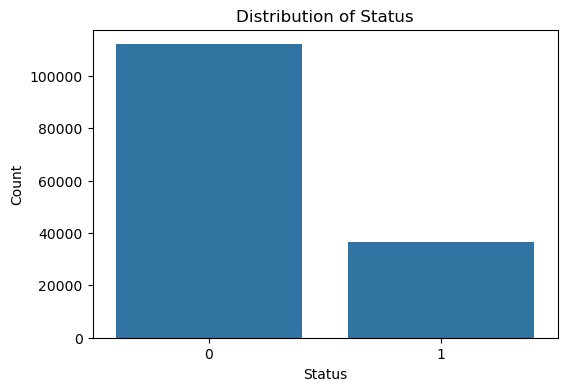

In [16]:
status_counts = df_github['Status'].value_counts().sort_index()
print("Status distribution:")
print(status_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_github, x='Status')
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

# Analysis of the types of values for each attribute

In [15]:
for column in df_github.columns:
    print(f"\n--- Attribute: {column} ---")
    if df_github[column].dtype in ['int64', 'float64']:
        print("Type: Numeric")
        print("Describing statistics:")
        print(df_github[column].describe())
        # Consider if it might be meta-numeric (numeric values used as labels)
        unique_numeric_values = df_github[column].nunique()
        if unique_numeric_values < 20 and unique_numeric_values > 0:
            print(f"potentially meta-numeric or categoric with {unique_numeric_values} unique values:\n{df_github[column].value_counts().sort_index()}")
    elif df_github[column].dtype == 'object':
        print("Type: categoric")
        print("Unique values and frequencies:")
        print(df_github[column].value_counts(dropna=False))
    else:
        print(f"Type: Other ({df_github[column].dtype})")


--- Attribute: ID ---
Type: Numeric
Describing statistics:
count    148670.000000
mean      99224.500000
std       42917.476598
min       24890.000000
25%       62057.250000
50%       99224.500000
75%      136391.750000
max      173559.000000
Name: ID, dtype: float64

--- Attribute: year ---
Type: Numeric
Describing statistics:
count    148670.0
mean       2019.0
std           0.0
min        2019.0
25%        2019.0
50%        2019.0
75%        2019.0
max        2019.0
Name: year, dtype: float64
potentially meta-numeric or categoric with 1 unique values:
year
2019    148670
Name: count, dtype: int64

--- Attribute: loan_limit ---
Type: categoric
Unique values and frequencies:
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

--- Attribute: Gender ---
Type: categoric
Unique values and frequencies:
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

--- Attribute: appr

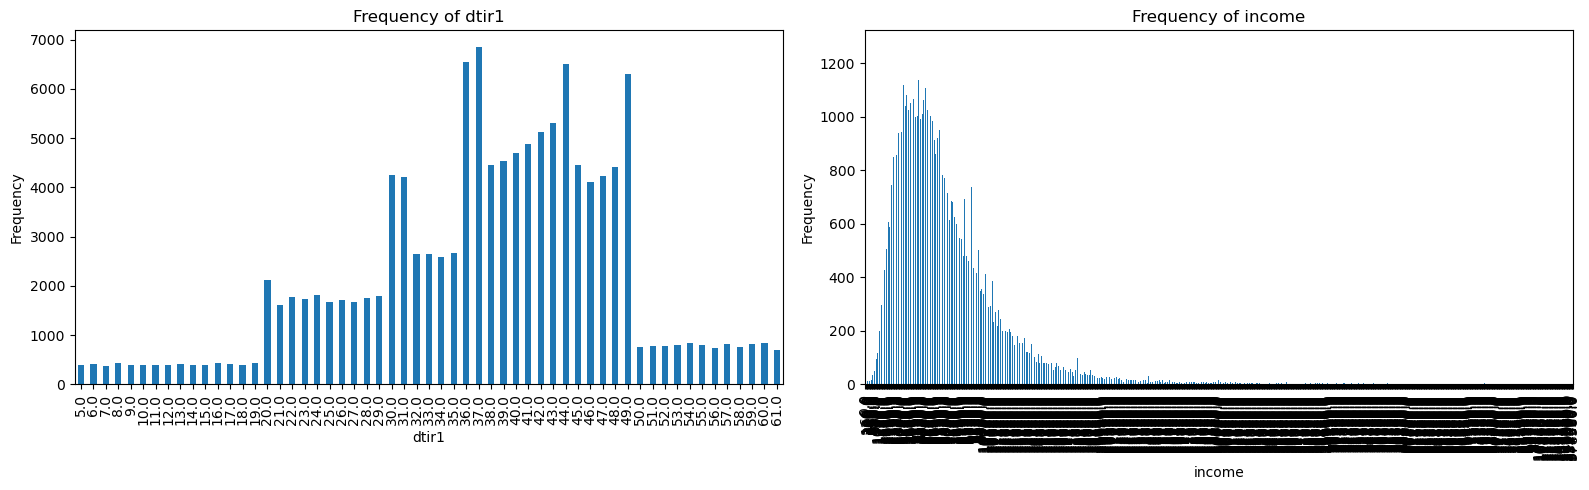

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# dtir1
dtir1_counts = df_github['dtir1'].dropna().value_counts().sort_index()
dtir1_counts.plot(kind='bar', ax=axes[0], rot=90)
axes[0].set_title('Frequency of dtir1')
axes[0].set_xlabel('dtir1')
axes[0].set_ylabel('Frequency')

# income
income_counts = df_github['income'].dropna().value_counts().sort_index()
income_counts.plot(kind='bar', ax=axes[1], rot=90)
axes[1].set_title('Frequency of income')
axes[1].set_xlabel('income')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
print("Missing values analysis")
missing = df_github.isnull().sum()
missing_pct = (missing / len(df_github) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Missing values analysis
                           Missing Values  Missing %
Upfront_charges                     39642      26.66
Interest_rate_spread                36639      24.64
rate_of_interest                    36439      24.51
dtir1                               24121      16.22
property_value                      15098      10.16
LTV                                 15098      10.16
income                               9150       6.15
loan_limit                           3344       2.25
approv_in_adv                         908       0.61
age                                   200       0.13
submission_of_application             200       0.13
loan_purpose                          134       0.09
Neg_ammortization                     121       0.08
term                                   41       0.03




*   UPFRONT CHARGES --> da levare perchè troppo oracolo
*   INTEREST RATE SPREAD --> Da levare perchè palese leakage
*   RATE OF INTEREST --> situazione analoga, probabilmente i record con default sono stati aggiunti dopo senza queste misure
*   DTIR1 --> sostituito con la mediana, la distribuzione è abbastanza simmetrica e la correlazione con status bassa.
*   PROPERTY VALUE e LTV --> levare colonna per non togliere troppi valori 1 default
*   INCOME --> sostituito con la mediana per lo stesso motivo di dtr1
*   LOAN LIMIT --> introdurre una nuova categoria "unknown" evitando di introdurre bias
*   AGE --> 200 record in cui manca e sono tutti default, si può togliere
*   SUBMISSION OF APPLICATION -> stesso di age
*   loan_purpose -> idem
*   Neg_ammortization -> idem
*   term -> idem





# Missing values analysis



### Upfront charges

In [ ]:
# Creazione di una variabile binaria per indicare la presenza di valori mancanti in 'Upfront_charges'
df_github['Upfront_charges_missing'] = df_github['Upfront_charges'].isnull().astype(int)

# Creazione della tabella di contingenza
contingency_table_upfront_missing = pd.crosstab(df_github['Upfront_charges_missing'], df_github['Status'])

df_github = df_github.drop(columns=['Upfront_charges_missing'])
print("Tabella di Contingenza: Upfront_charges_missing vs Status")
display(contingency_table_upfront_missing)

correlation_upfront_status = df_github['Upfront_charges_missing'].corr(df_github['Status'])
print(f"Correlation between Upfront_charges_missing and Status: {correlation_upfront_status:.4f}")

Tabella di Contingenza: Upfront_charges_missing vs Status


Status,0,1
Upfront_charges_missing,,
0,108875,153
1,3156,36486


Correlation between Upfront_charges_missing and Status: 0.9430


### Interest_rate_spread and rate_of_interest

In [27]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Interest_rate_spread_is_missing'] = df_github['Interest_rate_spread'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Interest_rate_spread_is_missing'], df_github['Status'], margins=True)
correlation = df_github['Interest_rate_spread_is_missing'].corr(df_github['Status'])

df_github = df_github.drop(columns=['Interest_rate_spread_is_missing'])
print("Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)")
display(leakage_table)
print(f"Correlation between Interest_rate_spread_is_missing and Status: {correlation:.4f}")

Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)


Status,0,1,All
Interest_rate_spread_is_missing,,,
0,112031,0,112031
1,0,36639,36639
All,112031,36639,148670


Correlation between Interest_rate_spread_is_missing and Status: 1.0000


In [28]:
# Create a binary flag: 1 if missing, 0 if present
df_github['ROImissing'] = df_github['rate_of_interest'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['ROImissing'], df_github['Status'], margins=True)
correlation = df_github['ROImissing'].corr(df_github['Status'])

df_github = df_github.drop(columns=['ROImissing'])
print("Contingency Table: ROImissing (Row) vs Status (Column)")
display(leakage_table)

print(f"Correlation between ROImissing and Status: {correlation:.4f}")

Contingency Table: ROImissing (Row) vs Status (Column)


Status,0,1,All
ROImissing,,,
0,112031,200,112231
1,0,36439,36439
All,112031,36639,148670


Correlation between ROImissing and Status: 0.9964


### dtir1

In [31]:
# Create a binary flag: 1 if missing, 0 if present
df_github['dtir1_ismissing'] = df_github['dtir1'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['dtir1_ismissing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['dtir1_ismissing'])

print("Contingency Table: dtir1_ismissing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: dtir1_ismissing (Row) vs Status (Column)


Status,0,1,All
dtir1_ismissing,,,
0,104220,20329,124549
1,7811,16310,24121
All,112031,36639,148670


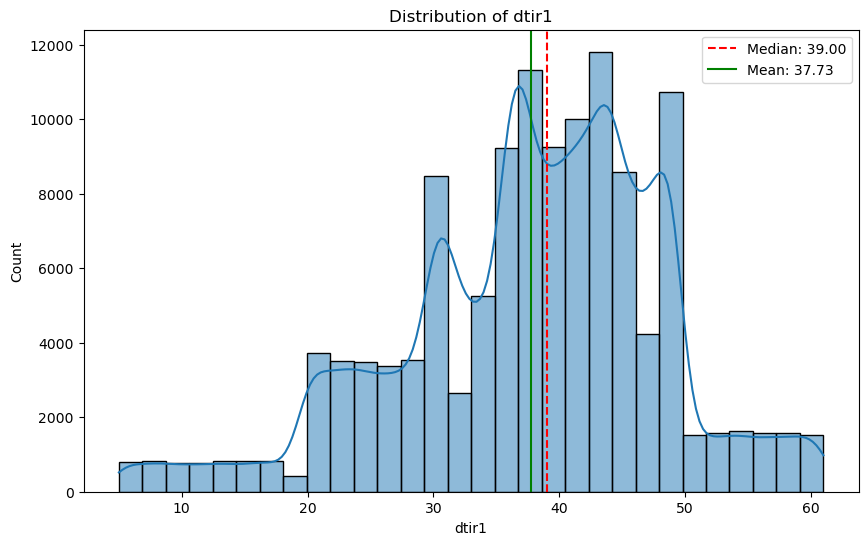

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_github['dtir1'].dropna(), kde=True, bins=30)
plt.title('Distribution of dtir1')
plt.axvline(df_github['dtir1'].median(), color='red', linestyle='--', label=f'Median: {df_github["dtir1"].median():.2f}')
plt.axvline(df_github['dtir1'].mean(), color='green', linestyle='-', label=f'Mean: {df_github["dtir1"].mean():.2f}')
plt.legend()
plt.show()

Given the distribution, the median is a safe choice for basic imputation. I'll also add a flag so the model knows the value was originally missing (which preserves that information).

In [33]:
# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['dtir1_quartiles'] = pd.qcut(df_github['dtir1'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

df_github = df_github.drop(columns=['dtir1_quartiles'])

Contingency Table (Percentages per Quartile):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",85.012430,14.987570
"(31.0, 39.0]",87.800437,12.199563
"(39.0, 45.0]",86.106446,13.893554
"(45.0, 61.0]",74.751344,25.248656



Contingency Table (Raw Counts):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",27357,4823
"(31.0, 39.0]",28932,4020
"(39.0, 45.0]",26662,4302
"(45.0, 61.0]",21269,7184


### Property value


In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['property_value_is_missing'] = df_github['property_value'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['property_value_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['property_value_is_missing'])
print("Contingency Table: property_value_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: property_value_is_missing (Row) vs Status (Column)


Status,0,1,All
property_value_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


### LTV


In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LTV_is_missing'] = df_github['LTV'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LTV_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LTV_is_missing'])
print("Contingency Table: LTV_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LTV_is_missing (Row) vs Status (Column)


Status,0,1,All
LTV_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


### Income

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['income_missing'] = df_github['income'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['income_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['income_missing'])
print("Contingency Table: income_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: income_missing (Row) vs Status (Column)


Status,0,1,All
income_missing,,,
0,104120,35400,139520
1,7911,1239,9150
All,112031,36639,148670


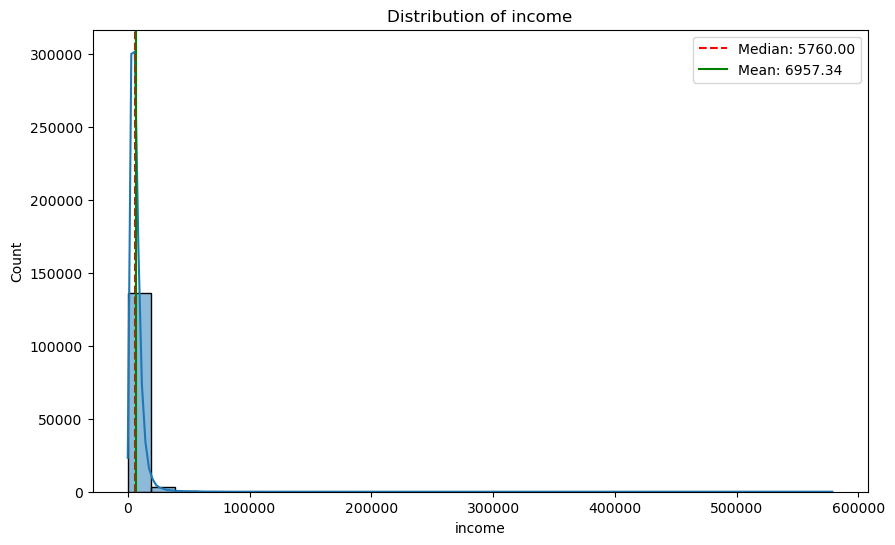

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df_github['income'].dropna(), kde=True, bins=30)
plt.title('Distribution of income')
plt.axvline(df_github['income'].median(), color='red', linestyle='--', label=f'Median: {df_github["income"].median():.2f}')
plt.axvline(df_github['income'].mean(), color='green', linestyle='-', label=f'Mean: {df_github["income"].mean():.2f}')
plt.legend()
plt.show()

In [ ]:
# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['income_quart'] = pd.qcut(df_github['income'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['income_quart'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['income_quart'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

df_github = df_github.drop(columns=['income_quart'])

Contingency Table (Percentages per Quartile):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",64.487808,35.512192
"(3720.0, 5760.0]",75.472125,24.527875
"(5760.0, 8520.0]",78.998601,21.001399
"(8520.0, 578580.0]",79.780220,20.219780



Contingency Table (Raw Counts):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",22770,12539
"(3720.0, 5760.0]",26656,8663
"(5760.0, 8520.0]",27106,7206
"(8520.0, 578580.0]",27588,6992


### Loan Limit

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LL_missing'] = df_github['loan_limit'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LL_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LL_missing'])
print("Contingency Table: LL_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LL_missing (Row) vs Status (Column)


Status,0,1,All
LL_missing,,,
0,109568,35758,145326
1,2463,881,3344
All,112031,36639,148670


### Age

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['age_missing'] = df_github['age'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['age_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['age_missing'])
print("Contingency Table: age_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: age_missing (Row) vs Status (Column)


Status,0,1,All
age_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


### Submission of application

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['submission_of_application_missing'] = df_github['submission_of_application'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['submission_of_application_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['submission_of_application_missing'])
print("Contingency Table: submission_of_application_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: submission_of_application_missing (Row) vs Status (Column)


Status,0,1,All
submission_of_application_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


In [ ]:
import pandas as pd

# Create flags for missing values
age_is_nan = df_github['age'].isnull()
submission_is_nan = df_github['submission_of_application'].isnull()

# Create a contingency table to see the overlap
overlap_table = pd.crosstab(age_is_nan, submission_is_nan,
                            rownames=['Age Missing'],
                            colnames=['Submission Missing'],
                            margins=True)

print("Overlap between missing Age and missing Submission of Application:")
display(overlap_table)

# Explicitly check if the indices match
same_records = (df_github[age_is_nan].index == df_github[submission_is_nan].index).all()
print(f"\nDo both columns have missing values in exactly the same records? {same_records}")

Overlap between missing Age and missing Submission of Application:


Submission Missing,False,True,All
Age Missing,,,
False,148470,0,148470
True,0,200,200
All,148470,200,148670



Do both columns have missing values in exactly the same records? True


200 records with missing age are the same 200 records with missing submission_of_application.


### Loan Purpose


In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['loan_purpose_missing'] = df_github['loan_purpose'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['loan_purpose_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['loan_purpose_missing'])
print("Contingency Table: loan_purpose_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: loan_purpose_missing (Row) vs Status (Column)


Status,0,1,All
loan_purpose_missing,,,
0,111932,36604,148536
1,99,35,134
All,112031,36639,148670


### Neg Ammortization

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Neg_ammortization_missing'] = df_github['Neg_ammortization'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Neg_ammortization_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['Neg_ammortization_missing'])
print("Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)


Status,0,1,All
Neg_ammortization_missing,,,
0,111942,36607,148549
1,89,32,121
All,112031,36639,148670


### Term

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['term_missing'] = df_github['term'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['term_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['term_missing'])
print("Contingency Table: term_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: term_missing (Row) vs Status (Column)


Status,0,1,All
term_missing,,,
0,112005,36624,148629
1,26,15,41
All,112031,36639,148670


## Null values


In [36]:
if 'Upfront_charges' in df_github.columns:
    df_github = df_github.drop(columns=['Upfront_charges'])
    print("Column 'Upfront_charges' dropped successfully.")
else:
    print("Column 'Upfront_charges' not found in the DataFrame. Skipping drop operation.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'Upfront_charges' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type',
       'Credit_Score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status',
       'dtir1'],
      dtype='object')


In [ ]:
columns_to_drop = ['rate_of_interest', 'Interest_rate_spread']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'rate_of_interest' dropped successfully.
Column 'Interest_rate_spread' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


In [37]:
# Reverting to median imputation for dtir1
median_val = df_github['dtir1'].median()
df_github['dtir1'] = df_github['dtir1'].fillna(median_val)

#print(f"Imputation complete. Missing values in 'dtir1': {df_github['dtir1'].isnull().sum()}")
#print(f"Median value used: {median_val}")

In [38]:
#Property value and LTV
columns_to_drop = ['property_value', 'LTV']

for col in columns_to_drop:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after dropping:")
print(df_github.columns)

Column 'property_value' dropped successfully.
Column 'LTV' dropped successfully.
Current columns in DataFrame after dropping:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by',
       'total_units', 'income', 'credit_type', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application',
       'Region', 'Security_Type', 'Status', 'dtir1'],
      dtype='object')


In [39]:
#Income
median_val = df_github['income'].median()
df_github['income'] = df_github['income'].fillna(median_val)

#print(f"Imputation complete. Missing values in 'income': {df_github['income'].isnull().sum()}")
#print(f"Median value used: {median_val}")

In [ ]:
# Sostituisci i valori nulli nella colonna 'loan_limit' con 'Unknown'
df_github['loan_limit'] = df_github['loan_limit'].fillna('Unknown')

print("Valori nulli nella colonna 'loan_limit' sostituiti con 'Unknown'.")
print("Valori unici e loro frequenze nella colonna 'loan_limit' dopo l'imputazione:")
print(df_github['loan_limit'].value_counts(dropna=False))

Valori nulli nella colonna 'loan_limit' sostituiti con 'Unknown'.
Valori unici e loro frequenze nella colonna 'loan_limit' dopo l'imputazione:
loan_limit
cf         135348
ncf          9978
Unknown      3344
Name: count, dtype: int64


In [ ]:
# Impute 'term' with its median
median_term = df_github['term'].median()
df_github['term'] = df_github['term'].fillna(median_term)
#print(f"Missing values in 'term' after imputation: {df_github['term'].isnull().sum()}")
#print(f"Median value used for 'term': {median_term}")

# Impute 'loan_purpose' with its mode (most frequent value)
## .mode()[0] is used to handle cases where there might be multiple modes
mode_loan_purpose = df_github['loan_purpose'].mode()[0]
df_github['loan_purpose'] = df_github['loan_purpose'].fillna(mode_loan_purpose)
#print(f"\nMissing values in 'loan_purpose' after imputation: {df_github['loan_purpose'].isnull().sum()}")
#print(f"Mode value used for 'loan_purpose': {mode_loan_purpose}")

##Impute 'Neg_ammortization' with its mode
mode_neg_ammortization = df_github['Neg_ammortization'].mode()[0]
df_github['Neg_ammortization'] = df_github['Neg_ammortization'].fillna(mode_neg_ammortization)
#print(f"\nMissing values in 'Neg_ammortization' after imputation: {df_github['Neg_ammortization'].isnull().sum()}")
#print(f"Mode value used for 'Neg_ammortization': {mode_neg_ammortization}")

##Impute 'approv_in_adv'
mode_approv_in_adv = df_github['approv_in_adv'].mode()[0]
df_github['approv_in_adv'] = df_github['approv_in_adv'].fillna(mode_approv_in_adv)


In [ ]:
initial_rows = df_github.shape[0]
print(f"Initial number of rows: {initial_rows}")

# Drop rows where 'age' is null
# As confirmed earlier, these are the same rows where 'submission_of_application' is null
if 'age' in df_github.columns:
    df_github.dropna(subset=['age'], inplace=True)
    print(f"Number of rows after dropping nulls in 'age': {df_github.shape[0]}")
    print(f"Rows dropped: {initial_rows - df_github.shape[0]}")
else:
    print("Column 'age' not found. Skipping operation.")

# Verify if 'submission_of_application' still has nulls (it shouldn't if 'age' and 'submission_of_application' nulls are coincident)
if 'submission_of_application' in df_github.columns:
    missing_submission = df_github['submission_of_application'].isnull().sum()
    print(f"Missing values in 'submission_of_application' after operation: {missing_submission}")
else:
    print("Column 'submission_of_application' not found.")

Initial number of rows: 148670
Number of rows after dropping nulls in 'age': 148470
Rows dropped: 200
Missing values in 'submission_of_application' after operation: 0


In [ ]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


##Duplicates


In [ ]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = df_github.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df_github[df_github.duplicated(keep=False)]) # keep=False shows all occurrences of duplicates
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


##Redundancies


In [ ]:
columns_to_remove = ['construction_type', 'Security_Type']

for col in columns_to_remove:
    if col in df_github.columns:
        df_github = df_github.drop(columns=[col])
        print(f"Column '{col}' removed successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame. Skipping.")

print("Current columns in DataFrame after removal:")
print(df_github.columns)

Column 'construction_type' removed successfully.
Column 'Security_Type' removed successfully.
Current columns in DataFrame after removal:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'occupancy_type', 'Secured_by',
       'total_units', 'income', 'credit_type', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application',
       'Region', 'Status', 'dtir1'],
      dtype='object')


###Noise


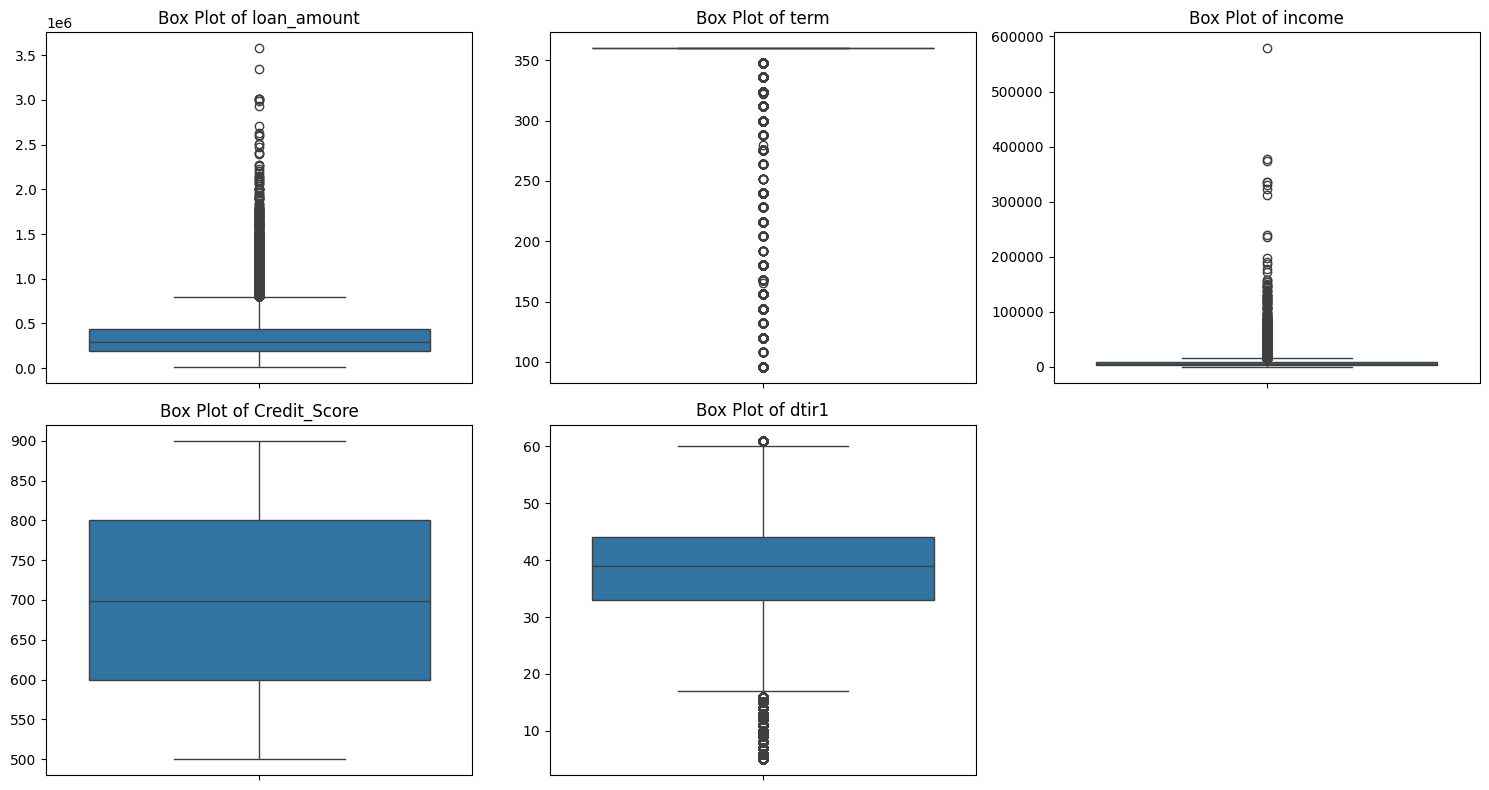

In [ ]:
# Select numerical columns for box plots
numerical_cols = df_github.select_dtypes(include=['int64', 'float64']).columns

# Filter out columns that might not be suitable for box plots (e.g., ID, or those with very few unique values that might be categorical)
numerical_cols = [col for col in numerical_cols if df_github[col].nunique() > 5 and col != 'ID' and col != 'Status' and col != 'year']

if not numerical_cols:
    print("No suitable numerical columns found for box plots after filtering.")
else:
    # Determine grid size
    n_cols = 3  # Number of columns in the plot grid
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    for i, col in enumerate(numerical_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=df_github[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel('') # Remove y-label to avoid clutter

    plt.tight_layout()
    plt.show()